In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [3]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


In [5]:
# Load Fashion MNIST training dataset
import os

# Use the downloaded path from kagglehub
dataset_path = path

# Load training CSV file
df = pd.read_csv(os.path.join(dataset_path, "fashion-mnist_train.csv"))



In [6]:
df.shape

(60000, 785)

In [7]:
df.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


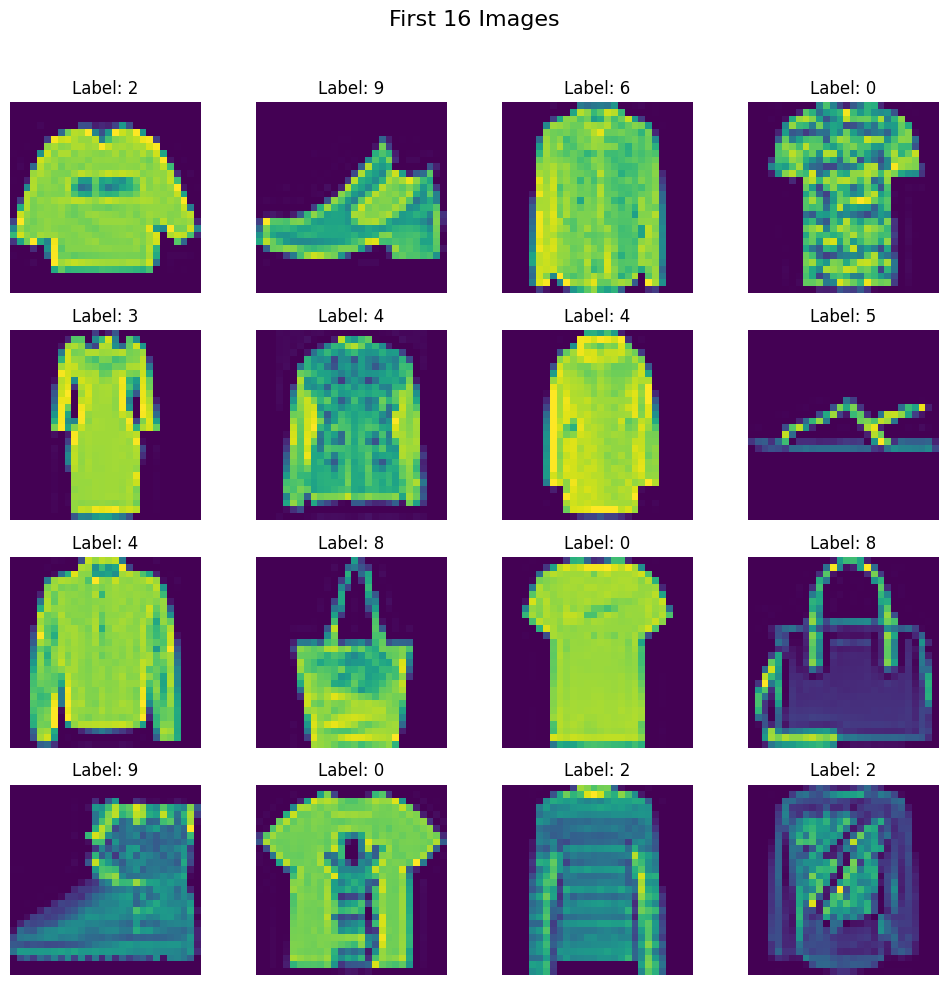

In [8]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [9]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train = X_train/255.0
X_test = X_test/255.0

In [12]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [13]:
train_dataset = CustomDataset(X_train, y_train)

In [14]:
test_dataset = CustomDataset(X_test, y_test)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [16]:
len(train_loader)

1500

In [17]:
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)

    )

  def forward(self, x):

    return self.model(x)


In [18]:
learning_rate = 0.1
epochs = 100

In [19]:
# instatiate the model
model = MyNN(X_train.shape[1])
model = model.to(device)
# loss function
criterion = nn.CrossEntropyLoss()
# optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [21]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.06760046622435524
Epoch: 2 , Loss: 0.06843607499268062
Epoch: 3 , Loss: 0.06612087479054025
Epoch: 4 , Loss: 0.0645111446591133
Epoch: 5 , Loss: 0.06267261031578043
Epoch: 6 , Loss: 0.05679955859835415
Epoch: 7 , Loss: 0.06402491082062867
Epoch: 8 , Loss: 0.06031099901821775
Epoch: 9 , Loss: 0.0571968475839191
Epoch: 10 , Loss: 0.05293720549248489
Epoch: 11 , Loss: 0.05981621380131643
Epoch: 12 , Loss: 0.05715245519739983
Epoch: 13 , Loss: 0.05813221095821548
Epoch: 14 , Loss: 0.0536174956606507
Epoch: 15 , Loss: 0.057682951579025636
Epoch: 16 , Loss: 0.049669837996635276
Epoch: 17 , Loss: 0.0511867010332353
Epoch: 18 , Loss: 0.04773005911809741
Epoch: 19 , Loss: 0.05563578390211721
Epoch: 20 , Loss: 0.045072914398289865
Epoch: 21 , Loss: 0.061245226880142584
Epoch: 22 , Loss: 0.056942725608804416
Epoch: 23 , Loss: 0.045984881941219406
Epoch: 24 , Loss: 0.047496524724561215
Epoch: 25 , Loss: 0.05090661617850856
Epoch: 26 , Loss: 0.05014301745437842
Epoch: 27 , Loss: 

In [ ]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8898333333333334


In [ ]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9824791666666667


Epoch: 1, Loss: 0.0641, Accuracy: 0.9836
Epoch: 2, Loss: 0.0606, Accuracy: 0.9851
Epoch: 3, Loss: 0.0603, Accuracy: 0.9750
Epoch: 4, Loss: 0.0542, Accuracy: 0.9819
Epoch: 5, Loss: 0.0518, Accuracy: 0.9855
Epoch: 6, Loss: 0.0505, Accuracy: 0.9823
Epoch: 7, Loss: 0.0535, Accuracy: 0.9857
Epoch: 8, Loss: 0.0585, Accuracy: 0.9549
Epoch: 9, Loss: 0.0656, Accuracy: 0.9742
Epoch: 10, Loss: 0.0538, Accuracy: 0.9621
Epoch: 11, Loss: 0.0476, Accuracy: 0.9811
Epoch: 12, Loss: 0.0503, Accuracy: 0.9794
Epoch: 13, Loss: 0.0488, Accuracy: 0.9798
Epoch: 14, Loss: 0.0501, Accuracy: 0.9815
Epoch: 15, Loss: 0.0522, Accuracy: 0.9809
Epoch: 16, Loss: 0.0573, Accuracy: 0.9754
Epoch: 17, Loss: 0.0478, Accuracy: 0.9834
Epoch: 18, Loss: 0.0525, Accuracy: 0.9787
Epoch: 19, Loss: 0.0456, Accuracy: 0.9778
Epoch: 20, Loss: 0.0451, Accuracy: 0.9773
Epoch: 21, Loss: 0.0445, Accuracy: 0.9869
Epoch: 22, Loss: 0.0364, Accuracy: 0.9876
Epoch: 23, Loss: 0.0427, Accuracy: 0.9813
Epoch: 24, Loss: 0.0408, Accuracy: 0.9862
E

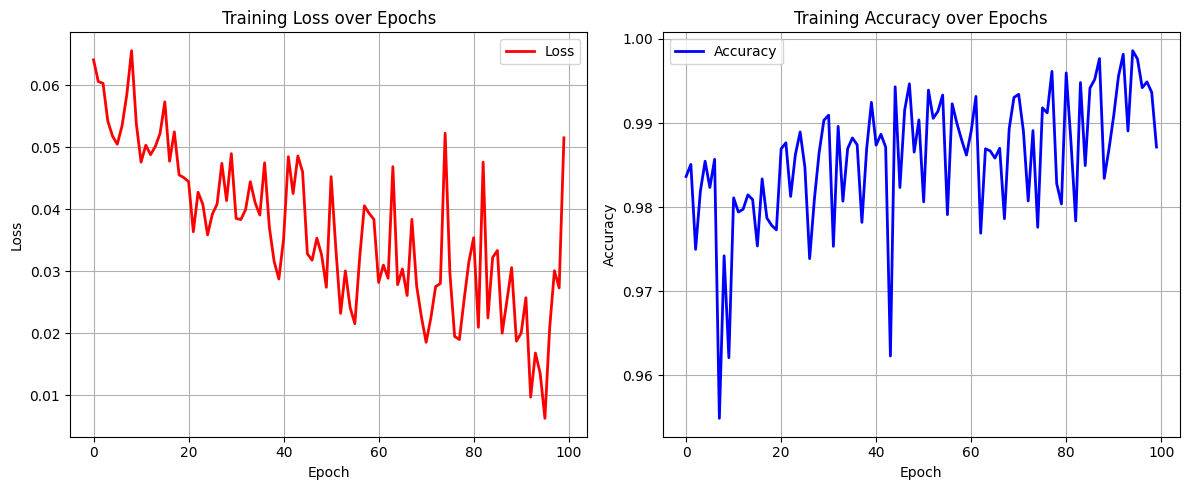

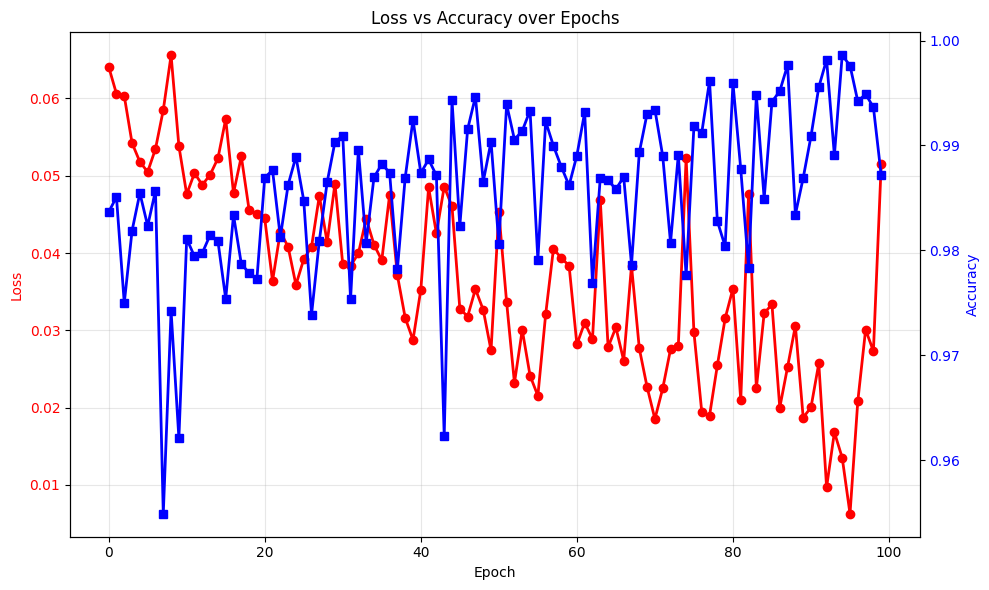

In [ ]:


# Plot Loss vs Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss', color='red', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Accuracy', color='blue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Combined plot
plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax1.plot(train_losses, label='Loss', color='red', linewidth=2, marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(train_accuracies, label='Accuracy', color='blue', linewidth=2, marker='s')
ax2.set_ylabel('Accuracy', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Loss vs Accuracy over Epochs')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
